   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


C:\Users\ravic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ravic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ravic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ravic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

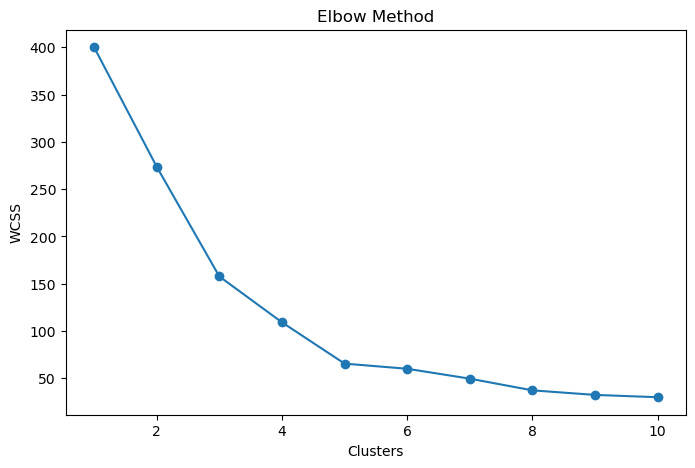

C:\Users\ravic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


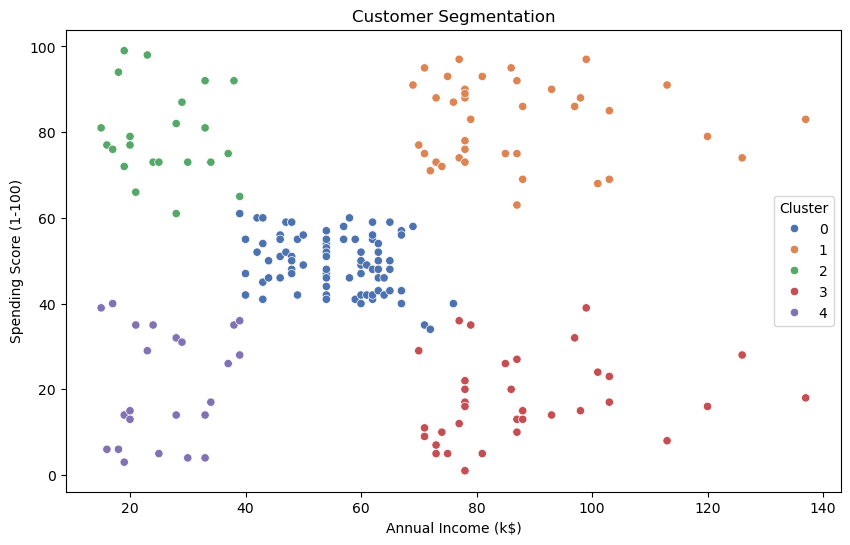

In [2]:
# ==========================================
# K-MEANS CLUSTERING
# CUSTOMER SEGMENTATION
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs(
    "../../../datasets/cleaned/kmeans",
    exist_ok=True
)

os.makedirs(
    "../../../datasets/processed/kmeans",
    exist_ok=True
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv(
    "../../../datasets/raw/mall_customers/Mall_Customers.csv"
)

print(df.head())

# ==========================================
# 2. CLEANING
# ==========================================

df = df.drop_duplicates()

df = df.dropna()

# ==========================================
# 3. SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "../../../datasets/cleaned/kmeans/cleaned_mall.csv",
    index=False
)

# ==========================================
# 4. FEATURE SELECTION
# ==========================================

X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# ==========================================
# 5. FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# 6. SAVE PROCESSED DATASET
# ==========================================

pd.DataFrame(X_scaled).to_csv(
    "../../../datasets/processed/kmeans/X_scaled.csv",
    index=False
)

# ==========================================
# 7. ELBOW METHOD
# ==========================================

wcss = []

for i in range(1, 11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

# ==========================================
# 8. ELBOW PLOT
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

# ==========================================
# 9. FINAL MODEL
# ==========================================

model = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = model.fit_predict(
    X_scaled
)

# ==========================================
# 10. ADD CLUSTERS
# ==========================================

df["Cluster"] = clusters

print(df.head())

# ==========================================
# 11. SAVE CLUSTER RESULTS
# ==========================================

df.to_csv(
    "../../../datasets/processed/kmeans/clustered_data.csv",
    index=False
)

# ==========================================
# 12. VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="deep"
)

plt.title("Customer Segmentation")

plt.show()

# ==========================================
# END
# ==========================================